In [19]:
from pathlib import Path
import importlib.util, sys
import pandas as pd
import torch
from IPython.display import SVG, display

REPO_ROOT = Path('/mnt/zzbnew/peixunban/chenyihao/fluProfiler')
ANALYSIS_DIR = REPO_ROOT / 'paper/Code/Fig4_SCMS_FiLM_20260902'
OUTPUT_ROOT = ANALYSIS_DIR / 'outputs'
OUTPUT_ROOT.mkdir(exist_ok=True)
spec = importlib.util.spec_from_file_location('fig4_scms', ANALYSIS_DIR / 'run_vaccine_selection.py')
fig4_scms = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = fig4_scms
spec.loader.exec_module(fig4_scms)


In [20]:
Crick_data = pd.read_csv(REPO_ROOT / 'data/dataset/H3_HA1_v1.0/processed/source.csv')
device = torch.device('cuda:0')
GPU_CACHE_GB, MAX_QUERIES_PER_TASK, TOP_N = 20, 32, 25
season_key = Crick_data['sheet'].astype(str).str.split('-', n=1).str[0]
Crick_early = Crick_data.loc[season_key.astype(int) <= 38].copy()
Crick_2023Feb = Crick_data.loc[season_key == '39'].copy()
Crick_2023Sep = Crick_data.loc[season_key == '40'].copy()
Crick_2024Feb = Crick_data.loc[season_key == '41'].copy()
Crick_2024Sep = Crick_data.loc[season_key == '42'].copy()
Crick_2025Feb = Crick_data.loc[season_key == '43'].copy()
Crick_2025Sep = Crick_data.loc[season_key == '44'].copy()

who_2023Feb = ['A/DARWIN/9/2021 EGG', 'A/DARWIN/6/2021 CELL']
who_2023Sep = ['A/THAILAND/8/2022 EGG', 'A/MASSACHUSETTS/18/2022 CELL']
who_2024Feb = who_2023Sep
who_2024Sep = ['A/CROATIA/10136RV/2023 EGG', 'A/DISTRICTOFCOLUMBIA/27/2023 CELL']
who_2025Feb = who_2024Sep
who_2025Sep = ['A/SINGAPORE/GP20238/2024 EGG', 'A/SYDNEY/1359/2024 CELL']
sup_vaccine = fig4_scms.supplement_candidates(Crick_data, fig4_scms.make_ha_lookup(Crick_data))


Skipping supplementary candidates without HA1 alignment/embedding: A/DARWIN/6/2021, A/SINGAPORE/GP20238/2024, A/SYDNEY/1359/2024, A/DISTRICTOFCOLUMBIA/27/2023


## 1. Vaccine recommendation

### 1.1 2023-2024 NH

In [21]:
serum_H3_2023Feb, virus_H3_2023Feb = fig4_scms.candidate_and_virus_tables(Crick_data, '39', sup_vaccine)
test_df_2023Feb = serum_H3_2023Feb.merge(virus_H3_2023Feb, how='cross')
print(f'{len(serum_H3_2023Feb):,} candidate sera × {len(virus_H3_2023Feb):,} target viruses')

141 candidate sera × 345 target viruses


/mnt/zzbnew/peixunban/chenyihao/fluProfiler/paper/Code/Fig4_SCMS_FiLM_20260902/run_vaccine_selection.py:231: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.close(fig)


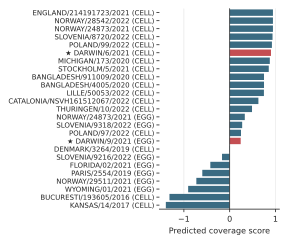

In [22]:
checkpoint = REPO_ROOT / 'results/H3_HA1_v1.0/20260902_161615/SCMS-FiLM-H3/season/39/subtype/H3N2_seed42/checkpoints/best_model.pth'
model, vocabs = fig4_scms.load_model(checkpoint, device)
test_df_2023Feb = fig4_scms.predict_pairs(test_df_2023Feb, model, vocabs, device, MAX_QUERIES_PER_TASK, GPU_CACHE_GB)
vaccine_2023Feb = fig4_scms.rank_candidates(test_df_2023Feb)
vaccine_2023Feb['coverage_score'] += 2
fig4_scms.plot_ranking(vaccine_2023Feb, '39', OUTPUT_ROOT / 'Fig4A.svg', TOP_N, who_2023Feb)
display(SVG(filename=OUTPUT_ROOT / 'Fig4A.svg'))
del model
torch.cuda.empty_cache()

### 1.2 2024 SH

In [23]:
# As in the reference notebook, add the two WHO sera from the following NH table.
who_vac = Crick_2024Feb.loc[Crick_2024Feb['serumName'].isin([x.rsplit(' ', 1)[0] for x in who_2023Sep])].copy()
serum_H3_2023Sep, virus_H3_2023Sep = fig4_scms.candidate_and_virus_tables(Crick_data, '40', who_vac)
test_df_2023Sep = serum_H3_2023Sep.merge(virus_H3_2023Sep, how='cross')

In [24]:
# vaccine_2023Sep[vaccine_2023Sep['serumName'] == 'A/THAILAND/8/2022']

/mnt/zzbnew/peixunban/chenyihao/fluProfiler/paper/Code/Fig4_SCMS_FiLM_20260902/run_vaccine_selection.py:231: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.close(fig)


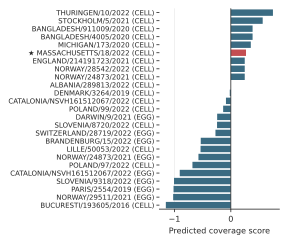

In [25]:
checkpoint = REPO_ROOT / 'results/H3_HA1_v1.0/20260902_161615/SCMS-FiLM-H3/season/40/subtype/H3N2_seed42/checkpoints/best_model.pth'
model, vocabs = fig4_scms.load_model(checkpoint, device)
test_df_2023Sep = fig4_scms.predict_pairs(test_df_2023Sep, model, vocabs, device, MAX_QUERIES_PER_TASK, GPU_CACHE_GB)
vaccine_2023Sep = fig4_scms.rank_candidates(test_df_2023Sep)
vaccine_2023Sep['coverage_score'] += 2
fig4_scms.plot_ranking(vaccine_2023Sep, '40', OUTPUT_ROOT / 'Fig4B.svg', TOP_N, who_2023Sep)
display(SVG(filename=OUTPUT_ROOT / 'Fig4B.svg'))
del model
torch.cuda.empty_cache()

### 1.3 2024-2025 NH

In [26]:
serum_H3_2024Feb, virus_H3_2024Feb = fig4_scms.candidate_and_virus_tables(Crick_data, '41', sup_vaccine)
test_df_2024Feb = serum_H3_2024Feb.merge(virus_H3_2024Feb, how='cross')

/mnt/zzbnew/peixunban/chenyihao/fluProfiler/paper/Code/Fig4_SCMS_FiLM_20260902/run_vaccine_selection.py:231: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.close(fig)


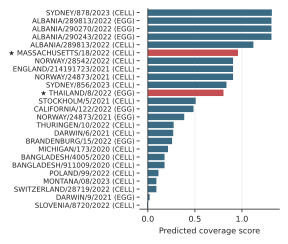

In [27]:
checkpoint = REPO_ROOT / 'results/H3_HA1_v1.0/20260902_161615/SCMS-FiLM-H3/season/41/subtype/H3N2_seed42/checkpoints/best_model.pth'
model, vocabs = fig4_scms.load_model(checkpoint, device)
test_df_2024Feb = fig4_scms.predict_pairs(test_df_2024Feb, model, vocabs, device, MAX_QUERIES_PER_TASK, GPU_CACHE_GB)
vaccine_2024Feb = fig4_scms.rank_candidates(test_df_2024Feb)
vaccine_2024Feb['coverage_score'] += 2
fig4_scms.plot_ranking(vaccine_2024Feb, '41', OUTPUT_ROOT / 'Fig4C.svg', TOP_N, who_2024Feb)
display(SVG(filename=OUTPUT_ROOT / 'Fig4C.svg'))
del model
torch.cuda.empty_cache()

### 1.4 2025 SH

In [28]:
serum_H3_2024Sep, virus_H3_2024Sep = fig4_scms.candidate_and_virus_tables(Crick_data, '42', sup_vaccine)
test_df_2024Sep = serum_H3_2024Sep.merge(virus_H3_2024Sep, how='cross')

/mnt/zzbnew/peixunban/chenyihao/fluProfiler/paper/Code/Fig4_SCMS_FiLM_20260902/run_vaccine_selection.py:231: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.close(fig)


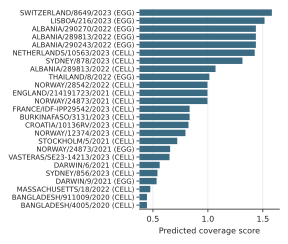

In [29]:
checkpoint = REPO_ROOT / 'results/H3_HA1_v1.0/20260902_161615/SCMS-FiLM-H3/season/42/subtype/H3N2_seed42/checkpoints/best_model.pth'
model, vocabs = fig4_scms.load_model(checkpoint, device)
test_df_2024Sep = fig4_scms.predict_pairs(test_df_2024Sep, model, vocabs, device, MAX_QUERIES_PER_TASK, GPU_CACHE_GB)
vaccine_2024Sep = fig4_scms.rank_candidates(test_df_2024Sep)
vaccine_2024Sep['coverage_score'] += 2
fig4_scms.plot_ranking(vaccine_2024Sep, '42', OUTPUT_ROOT / 'Fig4D.svg', TOP_N, who_2024Sep)
display(SVG(filename=OUTPUT_ROOT / 'Fig4D.svg'))
del model
torch.cuda.empty_cache()

### 1.5 2025-2026 NH

In [30]:
serum_H3_2025Feb, virus_H3_2025Feb = fig4_scms.candidate_and_virus_tables(Crick_data, '43', sup_vaccine)
test_df_2025Feb = serum_H3_2025Feb.merge(virus_H3_2025Feb, how='cross')

/mnt/zzbnew/peixunban/chenyihao/fluProfiler/paper/Code/Fig4_SCMS_FiLM_20260902/run_vaccine_selection.py:231: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.close(fig)


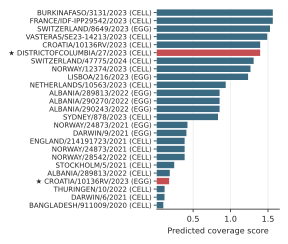

In [31]:
checkpoint = REPO_ROOT / 'results/H3_HA1_v1.0/20260902_161615/SCMS-FiLM-H3/season/43/subtype/H3N2_seed42/checkpoints/best_model.pth'
model, vocabs = fig4_scms.load_model(checkpoint, device)
test_df_2025Feb = fig4_scms.predict_pairs(test_df_2025Feb, model, vocabs, device, MAX_QUERIES_PER_TASK, GPU_CACHE_GB)
vaccine_2025Feb = fig4_scms.rank_candidates(test_df_2025Feb)
vaccine_2025Feb['coverage_score'] += 2
fig4_scms.plot_ranking(vaccine_2025Feb, '43', OUTPUT_ROOT / 'Fig4E.svg', TOP_N, who_2025Feb)
display(SVG(filename=OUTPUT_ROOT / 'Fig4E.svg'))
del model
torch.cuda.empty_cache()

### 1.6 2026 SH

In [32]:
serum_H3_2025Sep, virus_H3_2025Sep = fig4_scms.candidate_and_virus_tables(Crick_data, '44', sup_vaccine)
test_df_2025Sep = serum_H3_2025Sep.merge(virus_H3_2025Sep, how='cross')

/mnt/zzbnew/peixunban/chenyihao/fluProfiler/paper/Code/Fig4_SCMS_FiLM_20260902/run_vaccine_selection.py:231: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.close(fig)


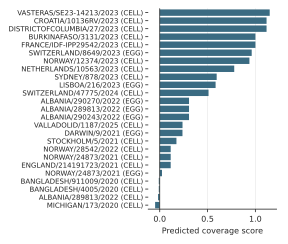

In [33]:
checkpoint = REPO_ROOT / 'results/H3_HA1_v1.0/20260902_161615/SCMS-FiLM-H3/season/44/subtype/H3N2_seed42/checkpoints/best_model.pth'
model, vocabs = fig4_scms.load_model(checkpoint, device)
test_df_2025Sep = fig4_scms.predict_pairs(test_df_2025Sep, model, vocabs, device, MAX_QUERIES_PER_TASK, GPU_CACHE_GB)
vaccine_2025Sep = fig4_scms.rank_candidates(test_df_2025Sep)
vaccine_2025Sep['coverage_score'] += 2
fig4_scms.plot_ranking(vaccine_2025Sep, '44', OUTPUT_ROOT / 'Fig4F.svg', TOP_N, who_2025Sep)
display(SVG(filename=OUTPUT_ROOT / 'Fig4F.svg'))
del model
torch.cuda.empty_cache()